# Lab 4 - Dashboard ejecutivo: lo que cuenta la historia

**Modalidad:** hands-on - **Duracion:** ~12 min

## El caso de negocio

El CFO nos pide en una sola pagina:

> «¿Compramos capacidad o la reducimos? ¿Reescribimos jobs? ¿Reforzamos equipos? ¿Cuanto nos cuesta la indisponibilidad?»

Esta pagina es la respuesta. 4 secciones, 1 cifra cada una.

## 0. Carga + limpieza minima del dashboard

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
metrics = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])
incidents = pd.read_csv(DATA / 'incidents.csv', parse_dates=['opened_at', 'resolved_at'])
runs = pd.read_csv(DATA / 'automation_runs.csv', parse_dates=['started_at'])
tickets = pd.read_csv(DATA / 'tickets.csv', parse_dates=['created_at'])

# Limpieza minima
for col, lo, hi in [('latency_ms', 0, 10_000), ('cpu_pct', 0, 100)]:
    metrics = metrics.loc[~((metrics[col] < lo) | (metrics[col] > hi))].copy()
    metrics[col] = metrics[col].fillna(metrics[col].median())
runs = runs.loc[~((runs['duration_sec'] < 0) | (runs['duration_sec'] > 86400))].copy()
tickets = tickets.loc[~((tickets['resolution_min'] <= 0) | (tickets['resolution_min'] > 100_000))].copy()
tickets['priority'] = tickets['priority'].fillna(tickets['priority'].mode().iloc[0])
tickets['team'] = tickets['team'].fillna(tickets['team'].mode().iloc[0])

## 1) Disponibilidad y SLOs

**Que decidimos:** si la disponibilidad observada esta por debajo del SLO (99.9%), hay que invertir en confiabilidad. Si esta por encima, podemos mover presupuesto a feature work.

Disponibilidad observada: 99.7727%
Burn-rate 5x medio: 2.44x



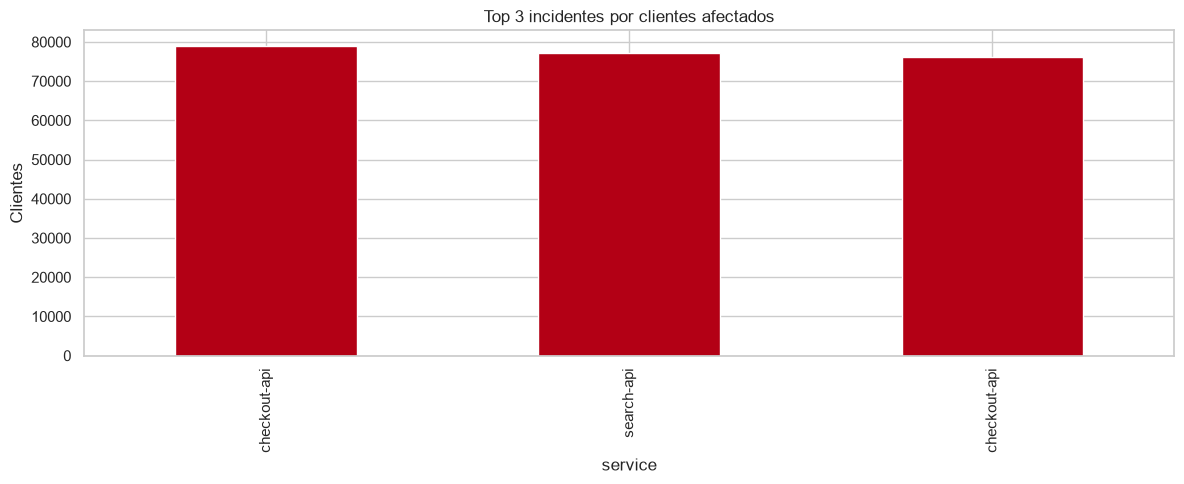

In [2]:
avail = 1 - metrics['error_rate'].mean()
burn_data = pd.read_csv(DATA / 'slo_burn.csv', parse_dates=['ts'])
burn_max = burn_data.groupby('incident_id')['burn_5x'].max().mean()
print(f'Disponibilidad observada: {avail:.4%}')
print(f'Burn-rate 5x medio: {burn_max:.2f}x')
print()
fig, ax = plt.subplots(figsize=(12, 5))
top3 = incidents.nlargest(3, 'customers_affected')[['service', 'customers_affected', 'mttr_min']]
top3.set_index('service')['customers_affected'].plot(kind='bar', color='#b30015', ax=ax)
ax.set_title('Top 3 incidentes por clientes afectados')
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.savefig('../html/lab4_fig1_avail.png', dpi=110, bbox_inches='tight')
plt.show()

## 2) Automatizacion - reescribimos o esperamos?

**Que decidimos:** si el success rate global esta bajo 95%, hay que reescribir jobs prioritarios. Si esta sobre 99%, podemos recortar personal.

Success rate global: 88.27%
Job con peor MTTR:
job_name
failover_drill    189.5
Name: duration_sec, dtype: float64



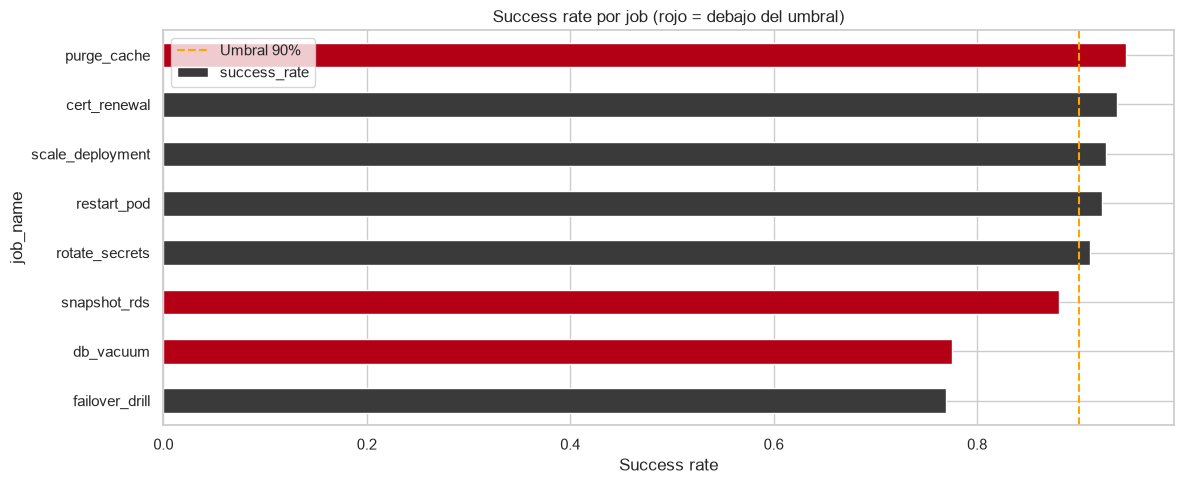

In [3]:
auto_ok = (runs['status'] == 'success').mean()
failed = runs[runs['status'].isin(['failed','timeout'])]
mttr_per_job = failed.groupby('job_name')['duration_sec'].median()
worst_job = mttr_per_job.sort_values(ascending=False).head(1)
print(f'Success rate global: {auto_ok:.2%}')
print(f'Job con peor MTTR:\n{worst_job}\n')

fig, ax = plt.subplots(figsize=(12, 5))
agg = runs.groupby('job_name').agg(
    runs=('run_id', 'count'),
    success_rate=('status', lambda s: (s == 'success').mean()),
)
colors = ['#b30015' if x < 0.9 else '#3a3a3a' for x in agg['success_rate']]
agg.sort_values('success_rate').plot(kind='barh', y='success_rate', color=colors, ax=ax)
ax.axvline(x=0.9, color='orange', linestyle='--', label='Umbral 90%')
ax.set_xlabel('Success rate')
ax.set_title('Success rate por job (rojo = debajo del umbral)')
ax.legend()
plt.tight_layout()
plt.savefig('../html/lab4_fig2_auto.png', dpi=110, bbox_inches='tight')
plt.show()

## 3) Demanda operativa - donde reforzamos?

**Que decidimos:** si un equipo lidera el breach + la carga, hay que reforzar. Si lidera el rollback, hay que mejorar el proceso de cambios.

Tickets/dia promedio: 19.1
Rollback rate (changes): 7.80%


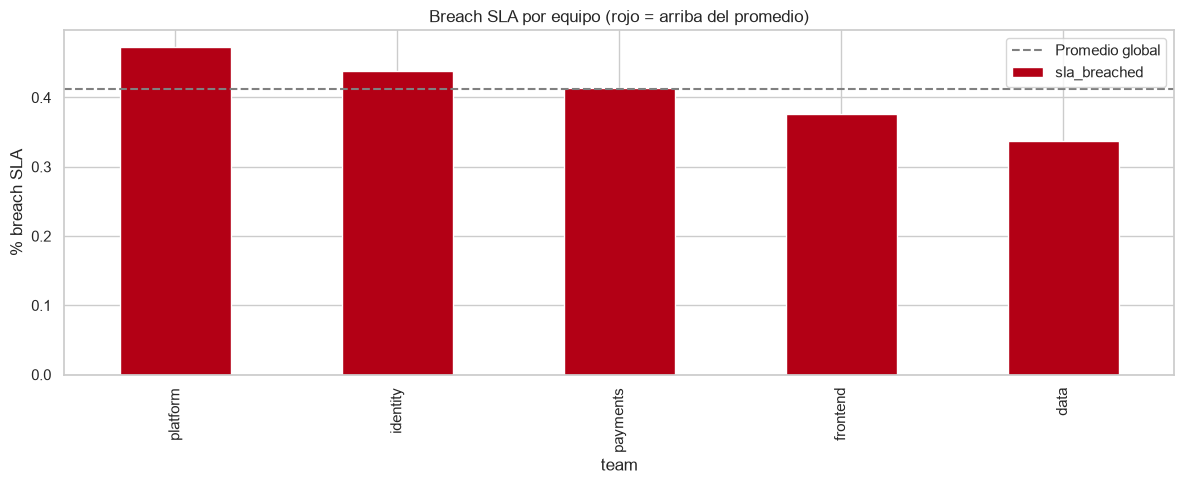

In [4]:
tickets['date'] = tickets['created_at'].dt.date
vol = tickets.groupby('date').size().mean()
rollback_rate = tickets.loc[tickets['category']=='change', 'rollback'].mean()
print(f'Tickets/dia promedio: {vol:.1f}')
print(f'Rollback rate (changes): {rollback_rate:.2%}')

fig, ax = plt.subplots(figsize=(12, 5))
tickets.groupby('team')['sla_breached'].mean().sort_values(ascending=False).plot(kind='bar', color='#b30015', ax=ax)
ax.axhline(y=tickets['sla_breached'].mean(), color='grey', linestyle='--', label='Promedio global')
ax.set_ylabel('% breach SLA')
ax.set_title('Breach SLA por equipo (rojo = arriba del promedio)')
ax.legend()
plt.tight_layout()
plt.savefig('../html/lab4_fig3_ops.png', dpi=110, bbox_inches='tight')
plt.show()

## 4) Recomendacion RICE

**Que decidimos:** priorizamos las acciones donde RICE = (Reach x Impact) / Effort es mayor.

In [5]:
recos = pd.DataFrame([
    {'accion': 'Comprar capacidad para checkout-api', 'reach': 9, 'impact': 4, 'effort': 3},
    {'accion': 'Reescribir job con peor MTTR', 'reach': 6, 'impact': 3, 'effort': 2},
    {'accion': 'Reforzar equipo con mas breach', 'reach': 7, 'impact': 3, 'effort': 2},
    {'accion': 'Implementar auto-scaling lunes 9-11am', 'reach': 8, 'impact': 2, 'effort': 1},
])
recos['rice'] = recos['reach'] * recos['impact'] / recos['effort']
recos.sort_values('rice', ascending=False)

,accion,reach,impact,effort,rice
3,Implementar auto-scaling lunes 9-11am,8,2,1,16.0
0,Comprar capacidad para checkout-api,9,4,3,12.0
2,Reforzar equipo con mas breach,7,3,2,10.5
1,Reescribir job con peor MTTR,6,3,2,9.0


## Headline ejecutiva - tu version final

Redacta en una linea por seccion (cifra + responsable + ventana + accion). Esta es la frase que leeras al CFO.